# Analyse des tirs NBA : données brutes, preprocessing et modèles testés

Ce notebook accompagne le rapport `test.md` : il exécute le code et affiche les figures, dans le même ordre (données brutes, preprocessing, modèles testés). Le traitement lui-même est dans le dossier `preprocessing/` ; le notebook l'appelle et commente les résultats, sans dupliquer la logique. Il se lance depuis le dossier `test/paul/`.

| Module | Rôle |
|---|---|
| `config.py` | réglages : fenêtre de saisons, règle de sélection des joueurs, seuils |
| `cleaning.py` | chargement, correction des coordonnées, doublons, incohérences, postes manquants |
| `features.py` | features, sélection des joueurs, découpages |
| `pipeline.py` | enchaînement, contrôles bloquants, export parquet |
| `validate.py` | validation indépendante des features |
| `check_leakage.py` | détection de fuite de données |
| `model_features.py` | liste des features et transformations avant le modèle |
| `baseline_preview.py` | premiers modèles, sans réglage |
| `feature_selection.py` | importance par permutation et sélection des 12 features |
| `figures.py` | figures et tests statistiques |

Prérequis : les CSV saisonniers décompressés dans `data/raw/shots_csv/` à la racine du dépôt (voir README).

In [1]:
%matplotlib inline
import json
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from preprocessing import config as C
from preprocessing import figures as F
from preprocessing import model_features as M

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# Relancer les traitements longs uniquement si leurs sorties n'existent pas encore.
FORCER = False


def show(resultat):
    """Affiche une figure du module figures.py et renvoie ses statistiques."""
    fig, stats = resultat
    display(fig)
    plt.close(fig)
    return stats

## Construction du dataset

Avant tout, je construis (ou recharge) le dataset : plusieurs figures en ont besoin. Le pipeline lit les 22 CSV, garde les 10 dernières saisons, nettoie, construit les features et exporte deux fichiers parquet. Il s'arrête si un contrôle de qualité échoue.

In [2]:
from preprocessing import pipeline

if FORCER or not C.SHOTS_MODEL_PATH.exists():
    audit = pipeline.run()
else:
    audit = json.loads(C.AUDIT_PATH.read_text(encoding="utf-8"))

pd.DataFrame([
    ("Lignes brutes (22 saisons)", audit["lignes_brutes"]),
    ("Saisons avant 2015-16, hors fenêtre", -audit["lignes_hors_fenetre"]),
    ("Libellé 'No Shot'", -audit["lignes_no_shot"]),
    ("Doublons supprimés (hors claquettes plausibles)", -audit["doublons_supprimes"]),
    ("Incohérences type / zone / distance", -audit["incoherences_union"]),
    ("Dataset final", audit["lignes_clean"]),
], columns=["Étape", "Lignes"])

,Étape,Lignes
0,Lignes brutes (22 saisons),4450789
1,"Saisons avant 2015-16, hors fenêtre",-2350533
2,Libellé 'No Shot',-81
3,Doublons supprimés (hors claquettes plausibles),-1
4,Incohérences type / zone / distance,-863
5,Dataset final,2099311


In [3]:
print("Coordonnées corrigées :", f"{audit['lignes_coordonnees_corrigees']:,}", "tirs, saisons", audit["saisons_echelle_corrompue"])
print("Contrôles bloquants (tous doivent valoir 0) :", audit["controles"])

Coordonnées corrigées : 595,821 tirs, saisons [2020, 2021, 2022]
Contrôles bloquants (tous doivent valoir 0) : {'cible_hors_0_1': 0, 'lignes_dupliquees_rid': 0, 'nulls_distance': 0, 'nulls_angle': 0, 'nulls_domicile': 0, 'nulls_jours_repos': 0, 'nulls_geste': 0, 'temps_hors_bornes': 0, 'domicile_incoherent': 0, 'hors_fenetre': 0, 'coordonnees_non_fiables': 0, 'experience_negative': 0, 'match_dans_plusieurs_splits': 0}


## 1. Les données brutes

4 450 789 tirs sur 22 saisons, 26 colonnes. Deux problèmes majeurs guident tout le reste.

### 1.1 Avant 2010-11, la position des tirs sous le panier est perdue

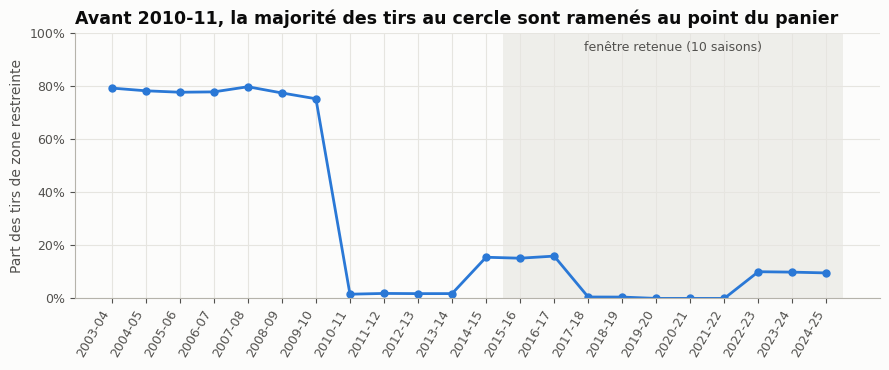

Tirs au point du panier : 77.8% avant 2010-11, 5.7% ensuite (z = 880)


In [4]:
st = show(F.fig_rupture_panier())
print(f"Tirs au point du panier : {st['part_avant']:.1%} avant 2010-11, {st['part_apres']:.1%} ensuite (z = {st['z']:.0f})")

**Lecture.** Jusqu'en 2009-10, 77,8 % des tirs sous le panier sont enregistrés au point du panier : leur position réelle est perdue. Ensuite, 5,7 % seulement.

### 1.2 Trois saisons ont des coordonnées fausses

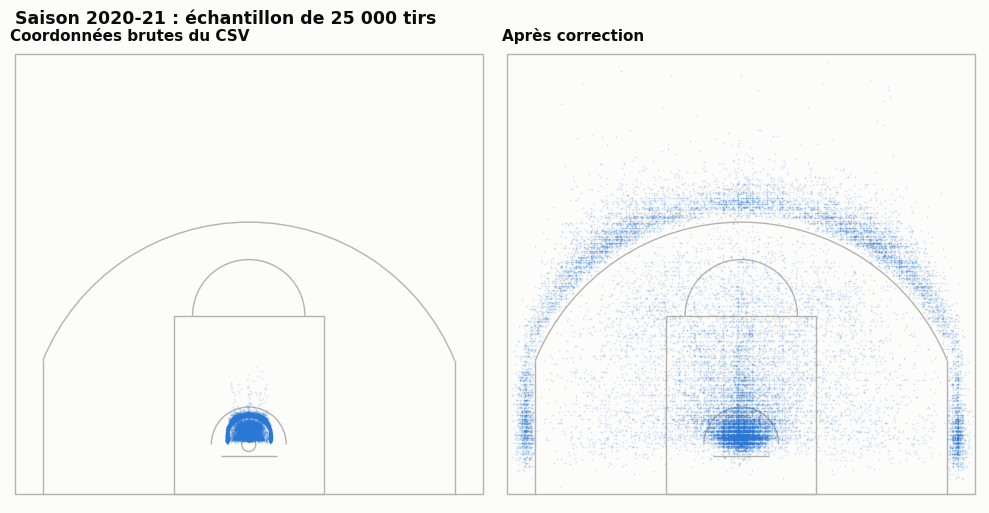

In [5]:
st = show(F.fig_shotchart_correction())

**Lecture.** En 2019-20, 2020-21 et 2021-22, `LOC_X` est divisé par 10 et de signe inversé, et `LOC_Y` vaut `5,25 + y / 10`. Dans le fichier brut (à gauche), tous les tirs sont tassés autour du panier ; après correction (à droite), l'arc à 3 points, les corners et le cercle réapparaissent.

## 2. Preprocessing

### 2.1 Périmètre

#### Pourquoi 10 saisons

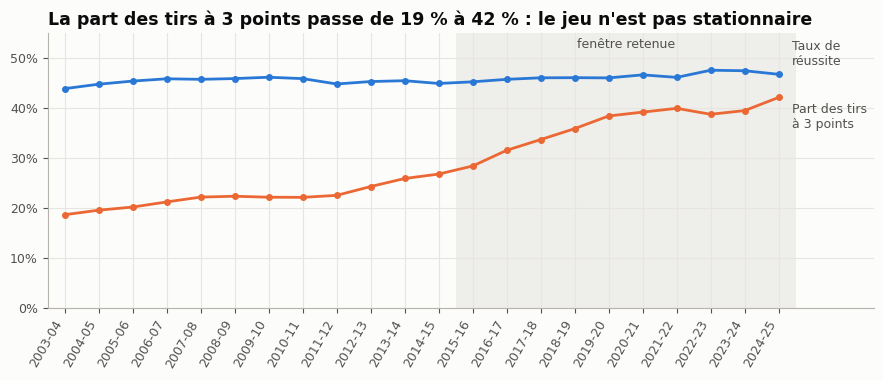

In [6]:
st = show(F.fig_derive_temporelle())

**Lecture.** Le jeu change : la part des tirs à 3 points passe de 19 % à 42 %. Avec la rupture de 2010-11 (§1.1), cela justifie une fenêtre de 10 saisons (2015-16 à 2024-25) : coordonnées fiables, jeu homogène, 2,1 millions de tirs.

#### Les joueurs : une règle

Top 25 ESPN, actif en 2024-25, au moins 5 saisons et 5 000 tirs dans la fenêtre.

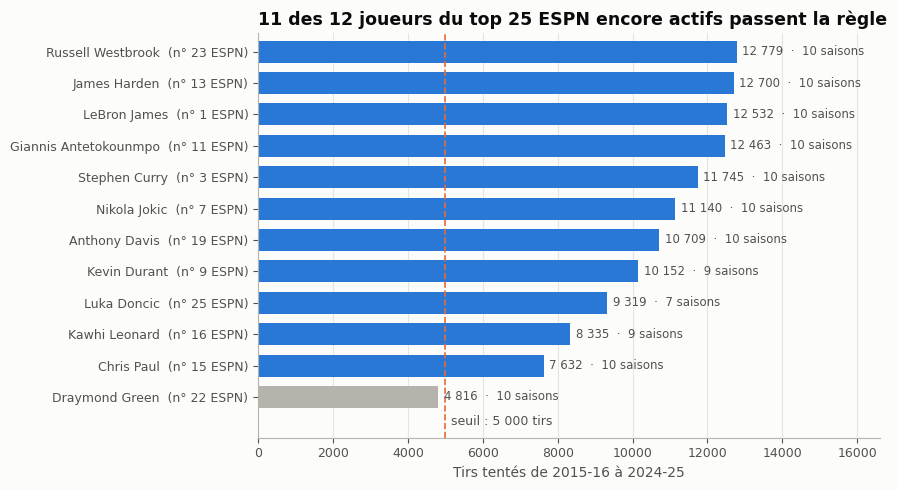

,rang_espn,joueur,tirs,saisons,derniere_saison,retenu
0,1,LeBron James,12532,10,2025,True
1,2,Kobe Bryant,1113,1,2016,False
2,3,Stephen Curry,11745,10,2025,True
3,4,Tim Duncan,441,1,2016,False
4,6,Kevin Garnett,115,1,2016,False
5,7,Nikola Jokic,11140,10,2025,True
6,8,Dwyane Wade,3778,4,2019,False
7,9,Kevin Durant,10152,9,2025,True
8,10,Dirk Nowitzki,2924,4,2019,False
9,11,Giannis Antetokounmpo,12463,10,2025,True


In [7]:
st = show(F.fig_couverture_joueurs())
pd.DataFrame(audit["selection_joueurs"])

**Lecture.** 11 joueurs passent la règle. Draymond Green est le seul actif écarté (4 816 tirs). Les retraités sont écartés par la règle « encore actif ».

### 2.2 Nettoyage : correction des coordonnées

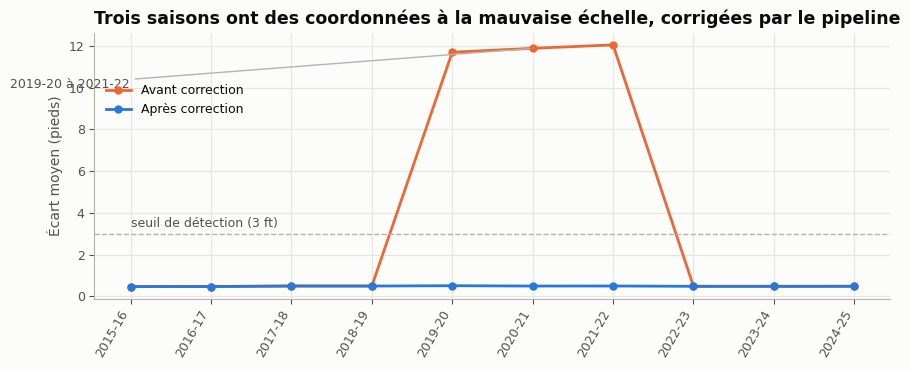

Écart avant : {2020: 11.69, 2021: 11.88, 2022: 12.04}
Écart après : {2020: 0.51, 2021: 0.49, 2022: 0.49}


In [8]:
st = show(F.fig_echelle_distance())
print("Écart avant :", {k: round(v, 2) for k, v in st["mae_avant_saisons_corrigees"].items()})
print("Écart après :", {k: round(v, 2) for k, v in st["mae_apres_saisons_corrigees"].items()})

**Lecture.** L'écart entre la distance recalculée et `SHOT_DISTANCE` atteint 12 pieds pour les trois saisons fausses. Après correction (`−x × 10`, `(y − 5,25) × 10`), il retombe à 0,5 pied, comme les autres saisons.

### 2.3 Features

32 features, toutes connues au moment où le joueur arme son tir (détail dans `dictionnaire_donnees.md`).

In [9]:
pd.DataFrame({
    "type": ["numérique"] * len(M.NUMERIC) + ["oui / non"] * len(M.BINARY) + ["catégorielle"] * len(M.CATEGORICAL),
    "feature": M.NUMERIC + M.BINARY + M.CATEGORICAL,
})

,type,feature
0,numérique,distance_ft
1,numérique,angle_deg
2,numérique,LOC_X
3,numérique,LOC_Y
4,numérique,temps_restant_periode_s
5,numérique,temps_ecoule_match_s
6,numérique,QUARTER
7,numérique,tirs_deja_pris
8,numérique,reussite_tirs_precedents
9,numérique,jours_repos


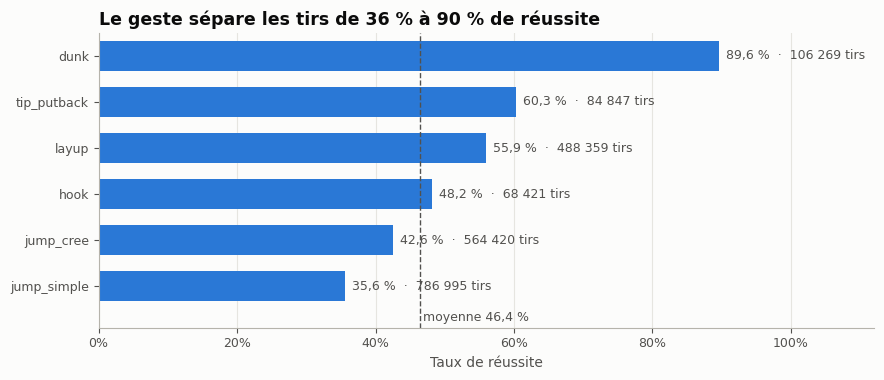

Khi-deux = 144,500 (5 ddl), p = 0.0e+00, V de Cramér = 0.262


In [10]:
st = show(F.fig_reussite_geste())
print(f"Khi-deux = {st['chi2']:,.0f} ({st['ddl']} ddl), p = {st['p_value']:.1e}, V de Cramér = {st['v_cramer']:.3f}")

**Lecture.** De 35,6 % (tir simple) à 89,6 % (dunk), avec un V de Cramér de 0,26 : le geste est fortement lié à la réussite.

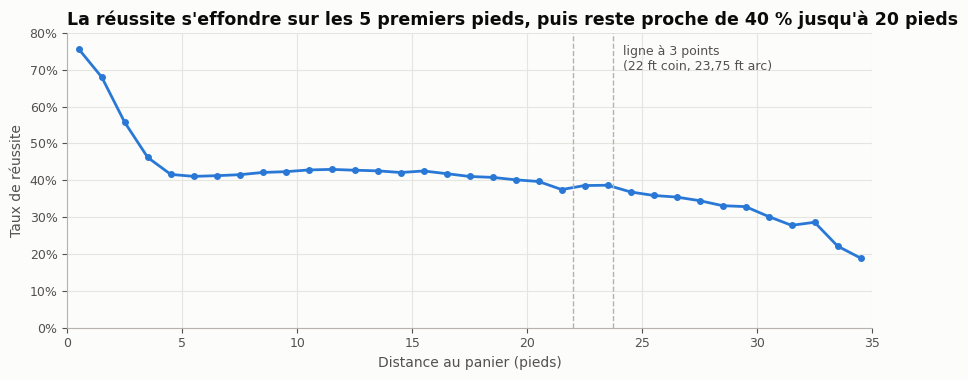

Point-bisériale r = -0.222, Spearman = -0.238


In [11]:
st = show(F.fig_reussite_distance())
print(f"Point-bisériale r = {st['r_point_biserial']:.3f}, Spearman = {st['spearman']:.3f}")

**Lecture.** Chute sur les 5 premiers pieds, plateau autour de 42 % jusqu'à 20 pieds, puis baisse derrière la ligne à 3 points : la relation n'est pas régulière.

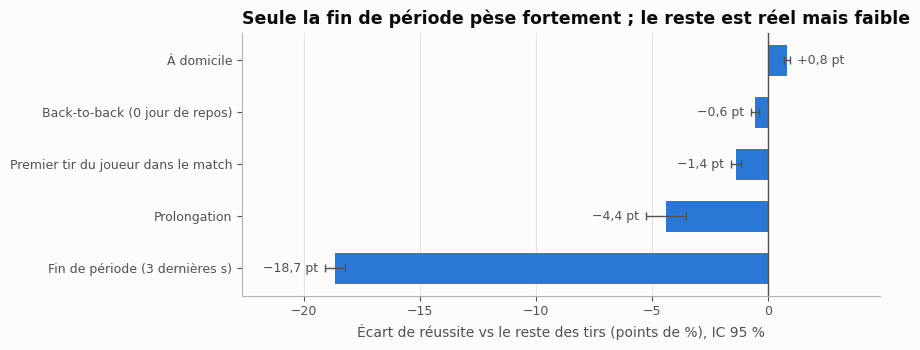

,p1,p2,diff_pts,ic95_pts,z,p_value
fin_de_periode,0.2809,0.4675,-18.6553,0.4273,-77.3090,0.0
premier_tir_match,0.4513,0.4652,-1.3932,0.2106,-12.9420,0.0
prolongation,0.4198,0.4639,-4.4064,0.8575,-9.9681,0.0
back_to_back,0.4591,0.4646,-0.5514,0.1755,-6.1536,0.0
domicile,0.4677,0.4595,0.8261,0.1349,12.0011,0.0


In [12]:
st = show(F.fig_effets_contexte())
pd.DataFrame(st).T[["p1", "p2", "diff_pts", "ic95_pts", "z", "p_value"]].round(4)

**Lecture.** Avec 2 millions de tirs, tout écart est significatif : c'est la taille de l'effet qui compte. Seule la fin de période pèse fortement (−18,7 points), surtout parce que les tirs au buzzer sont forcés. Domicile, repos et premier tir restent sous 1,5 point.

### 2.4 Dataset final et découpages

In [13]:
print(duckdb.sql(f"SELECT count(*) FROM read_parquet('{C.SHOTS_MODEL_PATH}')").fetchone()[0], "tirs")
display(duckdb.sql(f"SELECT * FROM read_parquet('{C.SHOTS_MODEL_PATH}') LIMIT 5").df())
display(duckdb.sql(f"""
    SELECT split, count(*) AS tirs, count(DISTINCT GAME_ID) AS matchs, round(avg(cible), 4) AS reussite
    FROM read_parquet('{C.SHOTS_MODEL_PATH}') GROUP BY 1 ORDER BY 1""").df())
display(duckdb.sql(f"""
    SELECT split_temps, count(*) AS tirs, min(SEASON_1) AS de, max(SEASON_1) AS a, round(avg(cible), 4) AS reussite
    FROM read_parquet('{C.SHOTS_MODEL_PATH}') GROUP BY 1 ORDER BY 1""").df())

2099311 tirs


,GAME_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,SEASON_1,GAME_DATE,joueur_projet,espn_top25,actif_2024_25,coord_corrigee,split,split_temps,distance_ft,angle_deg,LOC_X,LOC_Y,temps_restant_periode_s,temps_ecoule_match_s,QUARTER,tirs_deja_pris,reussite_tirs_precedents,jours_repos,saisons_depuis_premiere_apparition,domicile,fin_de_periode,derniere_minute,prolongation,tir_3pts,tir_planche,en_course,en_desequilibre,alley_oop,tir_backcourt,premier_tir_match,back_to_back,premier_match_saison,experience_censuree,geste_famille,ACTION_TYPE,BASIC_ZONE,POSITION_GROUP,POSITION,equipe,adversaire,cible
0,21500001,203083,Andre Drummond,1610612765,2016,2015-10-27,False,False,True,False,train,train,1.802776,109.440035,1.7,4.65,701,19,1,0,NaN,7,3,0,0,0,0,0,0,1,0,0,0,1,0,1,0,layup,Driving Layup Shot,Restricted Area,C,C,DET,ATL,0
1,21500001,202694,Marcus Morris Sr.,1610612765,2016,2015-10-27,False,False,False,False,train,train,13.482581,60.202409,-11.7,11.95,681,39,1,0,NaN,7,4,0,0,0,0,0,0,0,1,0,0,1,0,1,0,jump_cree,Step Back Jump shot,Mid-Range,F,SF,DET,ATL,1
2,21500001,200794,Paul Millsap,1610612737,2016,2015-10-27,False,False,False,False,train,train,12.165936,38.659808,-7.6,14.75,660,60,1,0,NaN,7,9,1,0,0,0,0,0,0,1,0,0,1,0,1,0,jump_cree,Step Back Jump shot,In The Paint (Non-RA),F,PF,ATL,DET,1
3,21500001,203484,Kentavious Caldwell-Pope,1610612765,2016,2015-10-27,False,False,True,False,train,train,8.500000,53.130102,6.8,10.35,644,76,1,0,NaN,7,2,0,0,0,0,0,0,1,0,0,0,1,0,1,0,jump_cree,Driving Floating Jump Shot,In The Paint (Non-RA),G,SG,DET,ATL,1
4,21500001,201143,Al Horford,1610612737,2016,2015-10-27,False,False,True,False,train,train,20.145719,35.504616,11.7,21.65,627,93,1,0,NaN,7,8,1,0,0,0,0,0,0,0,0,0,1,0,1,0,jump_simple,Jump Shot,Mid-Range,C,C,ATL,DET,0


,split,tirs,matchs,reussite
0,test,315479,1795,0.4642
1,train,1468817,8383,0.4634
2,val,315015,1797,0.4637


,split_temps,tirs,de,a,reussite
0,test,219515,2025,2025,0.4672
1,train,1661116,2016,2023,0.4617
2,val,218680,2024,2024,0.4744


### 2.5 Contrôles

#### Validation indépendante

In [14]:
from preprocessing import validate
val = validate.run() if FORCER or not (C.OUTPUT_DIR / "validation_report.json").exists() else \
    json.loads((C.OUTPUT_DIR / "validation_report.json").read_text(encoding="utf-8"))
pd.Series({k: v["ok"] for k, v in val.items() if isinstance(v, dict)}, name="réussi")

sequence_intra_match    True
temps                   True
jours_repos             True
domicile                True
geometrie_zones         True
experience              True
selection_joueurs       True
decoupages              True
schema                  True
Name: réussi, dtype: bool

#### Contrôle de fuite

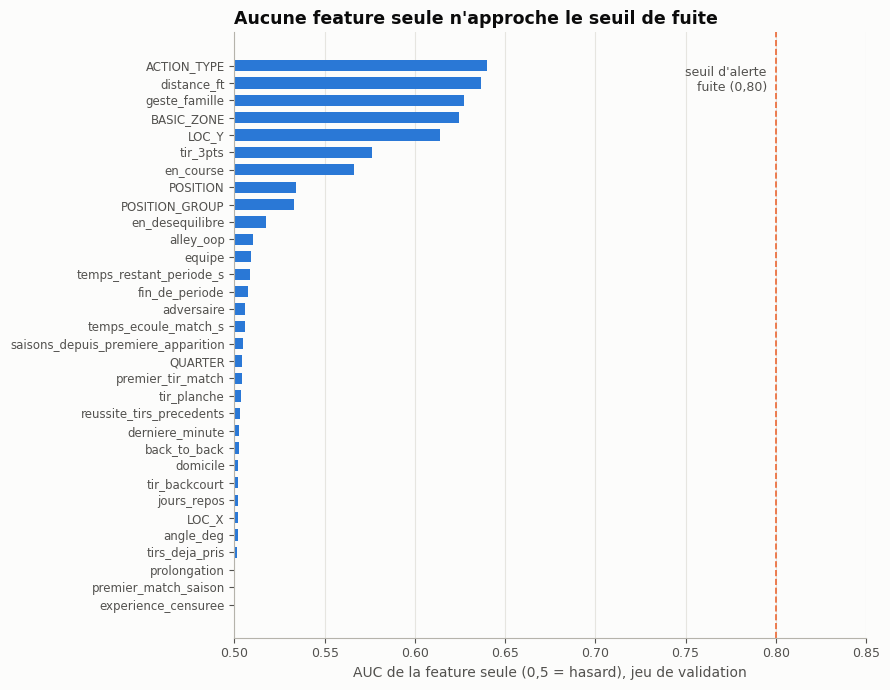

Verdict : aucune fuite detectee


In [15]:
from preprocessing import check_leakage
leak = check_leakage.run() if FORCER or not (C.OUTPUT_DIR / "leakage_check.json").exists() else \
    json.loads((C.OUTPUT_DIR / "leakage_check.json").read_text(encoding="utf-8"))
st = show(F.fig_auc_univariee())
print("Verdict :", leak["verdict"])

**Lecture.** Pour chaque feature, je mesure à quel point elle sépare seule les tirs réussis des tirs ratés (0,5 = aucune aide, 1 = parfait). La meilleure obtient 0,640, loin du seuil d'alerte de 0,80 : aucune feature ne « triche ».

## 3. Modèles testés

Deux modèles simples, **sans aucun réglage**. La note (AUC) va de 0,5 (hasard) à 1 (parfait) ; pour un tir NBA, le plafond réaliste est autour de 0,65 à 0,70.

In [16]:
from preprocessing import baseline_preview
prev = baseline_preview.run() if FORCER or not (C.OUTPUT_DIR / "baseline_preview.json").exists() else \
    json.loads((C.OUTPUT_DIR / "baseline_preview.json").read_text(encoding="utf-8"))
pd.DataFrame({
    "modèle": ["Hasard", "Régression logistique", "Gradient boosting", "Gradient boosting, saison 2024-25"],
    "note (AUC)": [0.5, prev["regression_logistique"]["auc"], prev["ablation_hgb"][-1]["auc"], prev["hgb_test_temporel"]["auc"]],
}).round(3)

,modèle,note (AUC)
0,Hasard,0.500
1,Régression logistique,0.653
2,Gradient boosting,0.670
3,"Gradient boosting, saison 2024-25",0.656


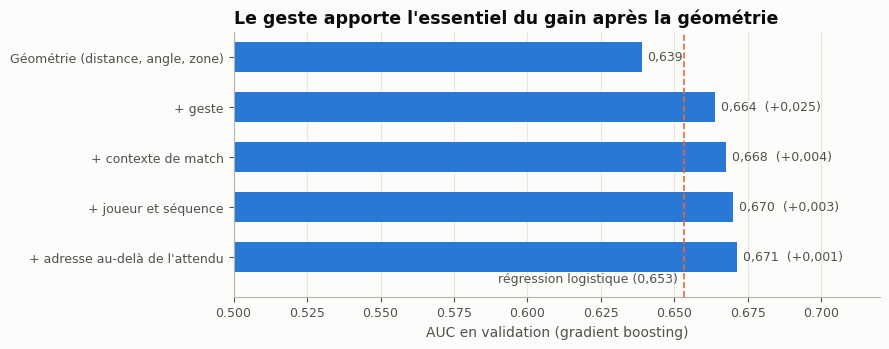

In [17]:
st = show(F.fig_ablation())

**Lecture.** La position du tir puis le geste apportent presque tout ; le contexte et le joueur n'ajoutent que quelques millièmes.

### Sélection de features

Je mélange au hasard une feature à la fois et je mesure de combien la note du modèle baisse.

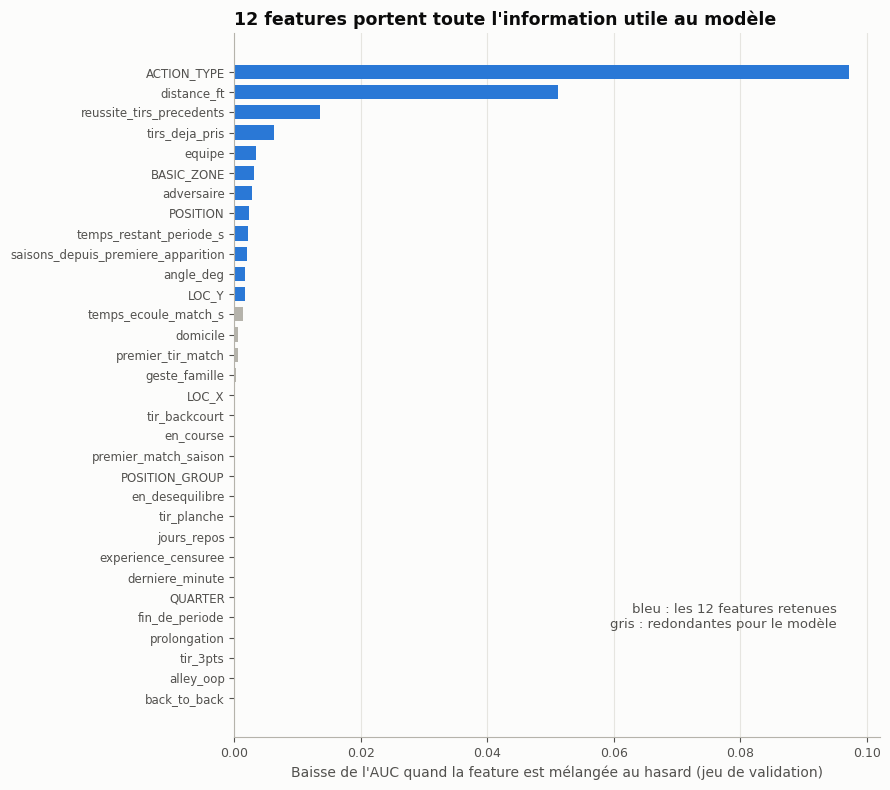

,nombre de features,note (AUC)
0,32,0.6707
1,12,0.6697
2,6,0.6644
3,2,0.6626


In [18]:
from preprocessing import feature_selection
fs = feature_selection.run() if FORCER or not (C.OUTPUT_DIR / "feature_selection.json").exists() else \
    json.loads((C.OUTPUT_DIR / "feature_selection.json").read_text(encoding="utf-8"))
st = show(F.fig_importance())
pd.DataFrame([(s["k"], round(s["auc"], 4)) for s in fs["sous_ensembles"]], columns=["nombre de features", "note (AUC)"])

**Lecture.** Avec les 12 features les plus utiles, la note est la même qu'avec les 32. Les 20 autres sont redondantes pour le modèle (leur information est déjà dans une autre), mais je les garde dans le dataset pour l'analyse des situations de jeu.

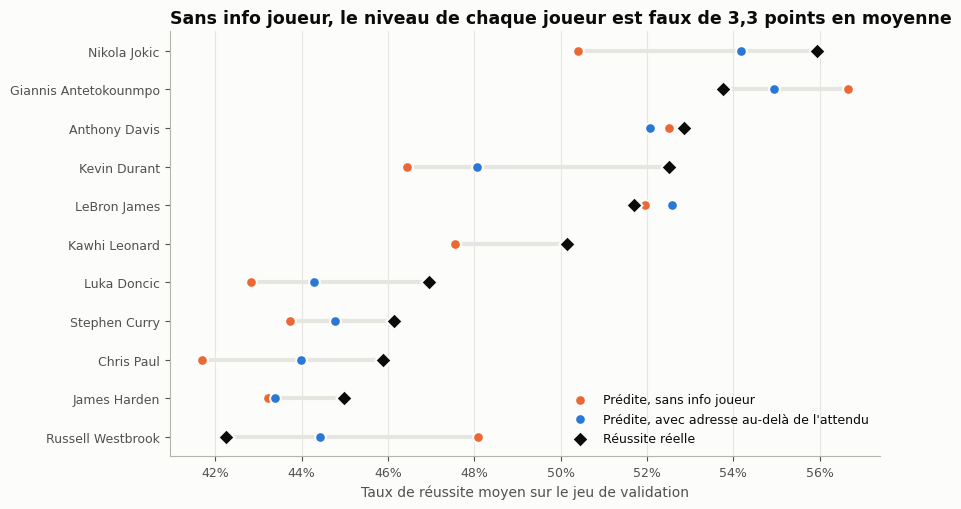

In [19]:
st = show(F.fig_calibration_joueurs())

**Lecture.** Sans information sur le joueur (points orange), le modèle se trompe de 3,3 points en moyenne sur le niveau de chaque joueur (Jokić : 50,4 % prédit, 55,9 % réel). Avec l'adresse du joueur au-delà de l'attendu (points bleus), l'erreur tombe à 1,7 point.

## Conclusion

Le dataset `shots_model.parquet` (2,1 millions de tirs, 32 features dont 12 utiles au modèle, 10 saisons) est propre, vérifié par un second code et sans fuite de données. Les premiers modèles atteignent déjà le niveau attendu ; la suite consiste à rendre juste la probabilité de chaque joueur (rapport, §3.5 et §5).